In [27]:
import sys
sys.path.append('../code')

import glob
import os
import jax
from jax import config
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from jax import jit, vmap
import joblib

import jaxley as jx
import jaxley.optimize.transforms as jt
from jaxley.connect import fully_connect, connect, sparse_connect, connectivity_matrix_connect
import optax
import pickle

import torch
from torch import optim
from sbi import utils as utils
from tqdm import tqdm

from network_utils import (make_network, set_train_parameters, get_currents, log_scale_forward, linear_scale_forward,
                           get_prior_dict, initialize_params)
from flow_utils import UniformPrior, PriorFiltered
from sklearn.linear_model import LinearRegression, Ridge

from neurodsp.spectral import compute_spectrum
from memorycontext_intrinsic_permutations import get_parameter_names

# import intrinsic_prior_configurations as prior_config
# save_path = '/users/ntolley/data/ntolley/dendractor/intrinsic_permutations_somaampa_dendnmda'
# config_list = [
    # ('Esoma_Isoma', prior_config.update_prior_dict_Esoma_Isoma), # 0
    # ('Edend_Idend', prior_config.update_prior_dict_Edend_Idend), # 1
    # ('Esoma_Idend', prior_config.update_prior_dict_Esoma_Idend), # 2
    # ('Edend_Isoma', prior_config.update_prior_dict_Edend_Isoma), # 3
    # ('Esoma_Isomadend', prior_config.update_prior_dict_Esoma_Isomadend), # 4
    # ('Edend_Isomadend', prior_config.update_prior_dict_Edend_Isomadend), # 5
    # ('Esomadend_Isoma', prior_config.update_prior_dict_Esomadend_Isoma), # 6
    # ('Esomadend_Idend', prior_config.update_prior_dict_Esomadend_Idend), # 7
    # ('Esomadend_Isomadend', prior_config.update_prior_dict_Esomadend_Isomadend) # 8
    # ]


import extrinsic_prior_configurations as prior_config
save_path = '/users/ntolley/data/ntolley/dendractor/extrinsic_permutations_subnetwork_outputs'
config_list = [
    # ('contextsoma_cuesoma', prior_config.update_prior_dict_contextsoma_cuesoma), # 0
    ('contextdend_cuedend', prior_config.update_prior_dict_contextdend_cuedend), # 1
    # ('contextsoma_cuedend', prior_config.update_prior_dict_contextsoma_cuedend), # 2
    # ('contextdend_cuesoma', prior_config.update_prior_dict_contextdend_cuesoma), # 3
    ]

def simulate_sweep(theta, params, cue_currents, context_currents, seed):
    seed_key = jax.random.split(jax.random.PRNGKey(seed), num=4)
    rng = np.random.default_rng(seed=123)

    key_order, conn_names, biophysics_names = get_parameter_names()

    # params is a list of single element dicitonaries, this is to just find the index
    key_mapping = {list(param_dict.keys())[0]: idx for idx, param_dict in enumerate(params)}
    theta_dict = {param_name: prior_dict[param_name]['rescale_function'](
        theta[param_idx], prior_dict[param_name]['bounds']) for 
        param_idx, param_name in enumerate(key_order)}

    # theta_dict['IE_gaba_gS'] *= 1
    # theta_dict['EE_ampa_gS'] *= 0

    # theta_dict['EI_ampa_gS'] *= 100
    # theta_dict['IE_gaba_gS'] *= 100
    # theta_dict['II_gaba_gS'] *= 100
    # theta_dict['EE_dend_ampa_gS'] *= 0.0
    # theta_dict['IE_dend_gaba_gS'] *= 0.0


    # Need to treat connections with special care
    # First create vector with identicial conductances for every synapse
    # Then mask out connections based on their probability
    for conn_name in conn_names:
        conn_g_name = f'{conn_name}_gS'
        conn_prob_name = f'{conn_name}_pconn'
        key_idx = key_mapping[conn_g_name]
        num_vals = len(params[key_idx][conn_g_name])

        new_vals = np.repeat(theta_dict[conn_g_name], num_vals)
        mask = rng.uniform(0, 1, size=num_vals) < theta_dict[conn_prob_name]
        new_vals = new_vals * mask

        params[key_idx][conn_g_name] = new_vals

    # No prob masking for biophysics, just update param vectors
    for param_name in biophysics_names:
        key_idx = key_mapping[param_name]
        num_vals = len(params[key_idx][param_name])

        new_vals = np.repeat(theta_dict[param_name], num_vals)
        params[key_idx][param_name] = new_vals


    net.delete_stimuli()
    
    noise_scale = 0.06
    # cue_noise = jax.random.normal(key=seed_key[0], shape=cue_currents.shape) * noise_scale
    # context_noise = jax.random.normal(key=seed_key[1], shape=context_currents.shape) * noise_scale


    # Only add noise during stim period
    cue_noise = jnp.zeros(shape=cue_currents.shape)
    context_noise = jnp.zeros(shape=context_currents.shape)
    stim_len = 1000
    cue_start = 28000
    cue_stop = cue_start + stim_len
    cue_noise = cue_noise.at[:, cue_start:cue_stop].set(
        jax.random.normal(key=seed_key[1], shape=(context_currents.shape[0], stim_len)) * noise_scale)

    cue_noise = cue_noise.at[:, 0:stim_len].set(
        jax.random.normal(key=seed_key[1], shape=(context_currents.shape[0], stim_len)) * noise_scale)
        
    context_start = 10000
    context_stop = context_start + stim_len
    context_noise = context_noise.at[:, context_start:context_stop].set(
        jax.random.normal(key=seed_key[2], shape=(context_currents.shape[0], stim_len)) * noise_scale)

    context_noise = context_noise.at[:, 0:stim_len].set(
        jax.random.normal(key=seed_key[2], shape=(context_currents.shape[0], stim_len)) * noise_scale)

    # Attach stimulation
    data_stimuli = net.cell(list(gid_ranges['cue'])).branch(0).comp(0).data_stimulate(cue_currents + cue_noise)
    data_stimuli = net.cell(list(gid_ranges['context'])).branch(0).comp(0).data_stimulate(
        context_currents + context_noise, data_stimuli=data_stimuli)

    vmin, vmax = -80, -40
    E_voltages = jax.random.uniform(key=seed_key[2], minval=vmin, maxval=vmax, shape=(len(net.cell(list(gid_ranges['E'])).nodes),))
    I_voltages = jax.random.uniform(key=seed_key[3], minval=vmin, maxval=vmax, shape=(len(net.cell(list(gid_ranges['I'])).nodes),))

    param_state = None
    param_state = net.cell(list(gid_ranges['E'])).data_set('v', E_voltages, param_state)
    param_state = net.cell(list(gid_ranges['I'])).data_set('v', I_voltages, param_state)


    net.delete_recordings()
    net.branch(0).comp(0).record('v')

    s = jx.integrate(net, t_max=t_max, params=params, data_stimuli=data_stimuli, param_state=param_state, delta_t=dt)
    return s

def get_opt_data(data_path):
    print(f'Loading data from: {data_path}')
    theta_list = list()
    error_list = list()

    num_flows = 3
    for flow_idx in range(num_flows):
        print(f'Flow {flow_idx}')
        theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
        error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')


        rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
        voltage_gids = list(gid_ranges['E'])

        theta_list.append(theta)
        error_list.append(error)


    error_sort = np.argsort(error_list)

    res_dict = {'theta_list': theta_list, 'error_list': error_list, 'error_sort': error_sort, 
                }

    return res_dict


In [28]:
dt = 0.025
t_max = 1000
time_vec = jnp.arange(0, t_max, dt)

downsample_factor = 10

for config_name, update_prior_dict in config_list:
    data_path = f'{save_path}/{config_name}'

    with open(f'{data_path}/jaxley_net.pkl', 'rb') as f:
        net, gid_ranges = pickle.load(f)

    res_dict = get_opt_data(data_path)

    # # Choose best from all sims
    # theta = np.concatenate(res_dict['theta_list'], axis=0)
    # error = np.concatenate(res_dict['error_list'])
    # theta_sort = np.argsort(error)
    # theta_idx = theta_sort[0]

    # Choose theta with error closest to target error
    # target_error = 0.25
    # theta = np.concatenate(res_dict['theta_list'], axis=0)
    # error = np.concatenate(res_dict['error_list'])
    # theta_idx = np.argmin(np.abs(error - target_error))

    # # Choose best from last run
    theta = res_dict['theta_list'][-1]
    error = res_dict['error_list'][-1]
    theta_sort = np.argsort(error)
    theta_idx = theta_sort[0]

    # Manual theta
    # theta = res_dict['theta_list'][-1]
    # theta_idx = 10


    print(f"Starting error: {error[theta_idx]}")

    num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
    num_cue_cells = len(gid_ranges['cue'])

    params, _ = set_train_parameters(net, gid_ranges)
    prior_dict = get_prior_dict()
    update_prior_dict(prior_dict)

    input_list = jnp.array([[-2,-2,1], [2,2,1], [-2, 2,1], [2,-2,1],
                            [-2,-2,-1], [2,2,-1], [-2, 2,-1], [2,-2,-1]])
    # input_list = jnp.array([[-2,-2,1], [2,2,1],
    #                         [-2,-2,-1], [2,2,-1]])
    num_cond = input_list.shape[0]
    input_data = [get_currents(input_list[idx], gid_ranges, t_max, dt) for idx in range(num_cond)]
    cue_currents = jnp.stack([input_data[idx][0] for idx in range(num_cond)])
    context_currents = jnp.stack([input_data[idx][1] for idx in range(num_cond)])
    targets = np.concatenate([input_data[idx][2][:2, ::downsample_factor] for idx in range(num_cond)], axis=1).T
    targets_stacked = jnp.stack([input_data[idx][2][:2, ::downsample_factor] for idx in range(num_cond)])

    batch_size = 5
    cue_currents_batch = jnp.tile(cue_currents, (batch_size, 1, 1))
    context_currents_batch = jnp.tile(context_currents, (batch_size, 1, 1))
    print(cue_currents_batch.shape)

    jitted_simulate = jit(simulate_sweep)
    jitted_vmapped_simulate = vmap(jitted_simulate, in_axes=(0, None, 0, 0, 0))

    best_theta = theta[theta_idx:theta_idx+1, :]
    
    # Run simulations in batch
    num_random_init = 10
    seed_array = jnp.arange(0, num_cond*num_random_init)

    output_list = list()
    for start_idx in range(0, num_random_init, batch_size):
        print(f'Batch: {start_idx}')
        end_idx = np.min([start_idx + batch_size, num_random_init])

        theta_batch = jnp.repeat(best_theta, num_cond * (end_idx - start_idx), axis=0)
        seed_batch = seed_array[start_idx*num_cond:end_idx*num_cond]

        output = np.array(jitted_vmapped_simulate(theta_batch, params, cue_currents_batch, context_currents_batch, seed_batch))
        output = output[:, :, ::downsample_factor]
        output_list.append(output)
    output_array = np.concatenate(output_list)

    random_init_dict = {
        'name': config_name,
        'output_array': output_array,
        'targets': targets,
        'targets_stacked': targets_stacked,
        'input_list': input_list,
        'theta': theta,
        'gid_ranges': gid_ranges
    }

    # random_init_save_path = f'{save_path}/random_initialization'
    # fname = f'{config_name}_random_init.pkl'
    # with open(f'{random_init_save_path}/{fname}', 'wb') as f:
    #     pickle.dump(random_init_dict,f)

Loading data from: /users/ntolley/data/ntolley/dendractor/extrinsic_permutations_subnetwork_outputs/contextdend_cuedend
Flow 0
Flow 1
Flow 2
Starting error: 1.7674108057022502
Number of newly added trainable parameters: 219. Total number of trainable parameters: 219
Number of newly added trainable parameters: 98. Total number of trainable parameters: 317
Number of newly added trainable parameters: 221. Total number of trainable parameters: 538
Number of newly added trainable parameters: 438. Total number of trainable parameters: 976
Number of newly added trainable parameters: 432. Total number of trainable parameters: 1408
Number of newly added trainable parameters: 218. Total number of trainable parameters: 1626
Number of newly added trainable parameters: 191. Total number of trainable parameters: 1817
Number of newly added trainable parameters: 185. Total number of trainable parameters: 2002
Number of newly added trainable parameters: 191. Total number of trainable parameters: 2193
N

In [29]:
t_max = 1000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = 30_000 // downsample_factor
# burn_in = 10_000 // downsample_factor

In [31]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
target_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_x_train_list = list()
    temp_target_train_list = list()
    # for cond_idx in range(num_cond):
    for cond_idx in [0,1,4,5]:
        temp_x_train_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], burn_in:])
        temp_target_train_list.append(targets_stacked[cond_idx, :, burn_in:])
    x_train.append(np.concatenate(temp_x_train_list, axis=1).T)
    target_train.append(np.concatenate(temp_target_train_list, axis=1).T)


num_model_sims = 8


error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x for x in x_train[:num_model_sims]])
target_fit = np.concatenate([y for y in target_train[:num_model_sims]])
model.fit(rate_fit, target_fit)

# for sim_idx in range(num_model_sims, len(x_train)):
for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred)


    error = np.mean(np.square(target_train[sim_idx] - y_pred))
    error_list.append(error)
print(error_list[:num_model_sims])
print(error_list[num_model_sims:])

[np.float64(2.8137189444624413), np.float64(3.2726404632007013), np.float64(2.378975392341367), np.float64(2.104610683378563), np.float64(2.911365910581252), np.float64(2.113712195400267), np.float64(3.8515340864273497), np.float64(2.3630372124278085)]
[np.float64(3.859923274003941), np.float64(6.1485812263578055)]


In [32]:
y_pred_list = list()
target_list = list()

val_idx = 9
sim_start_idx = val_idx * num_cond
for cond_idx in range(num_cond):
    rate_plot_data = output_array[sim_start_idx + cond_idx, gid_ranges['E_rate'], :].T
    y_pred = model.predict(rate_plot_data)

    y_pred_list.append(y_pred)
    target_list.append(random_init_dict['targets_stacked'][cond_idx, :, :].T)

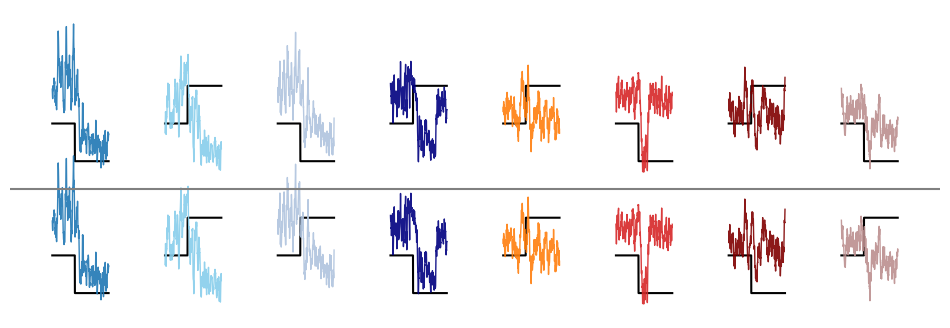

In [33]:
color_list = ['C0', 'skyblue', 'lightsteelblue', 'navy', 'C1', 'C3', 'maroon', 'rosybrown']
# time_offset = 3000
time_offset = 1000
y_offset = -7
# y_offset = -20
plt.figure(figsize=(12,4))

plot_burn_in = 2000
for cond_idx in range(num_cond):
    x_offset = time_offset * cond_idx
    
    plt.plot(time_vec[plot_burn_in:] + x_offset, target_list[cond_idx][plot_burn_in:-1, 0], color='k')
    plt.plot(time_vec[plot_burn_in:] + x_offset, y_pred_list[cond_idx][plot_burn_in:-1, 0], color=color_list[cond_idx], alpha=0.9, linewidth=1)

    plt.plot(time_vec[plot_burn_in:] + x_offset, target_list[cond_idx][plot_burn_in:-1, 1] + y_offset, color='k')
    plt.plot(time_vec[plot_burn_in:] + x_offset, y_pred_list[cond_idx][plot_burn_in:-1, 1] + y_offset, color=color_list[cond_idx], alpha=0.9, linewidth=1)


    plt.axis('off')
plt.axhline(y_offset/2, color='grey', linestyle='-')
# plt.axvline((time_offset * 4) - 500, color='grey', linestyle='-')
# plt.savefig('full_trajectory_set.svg')

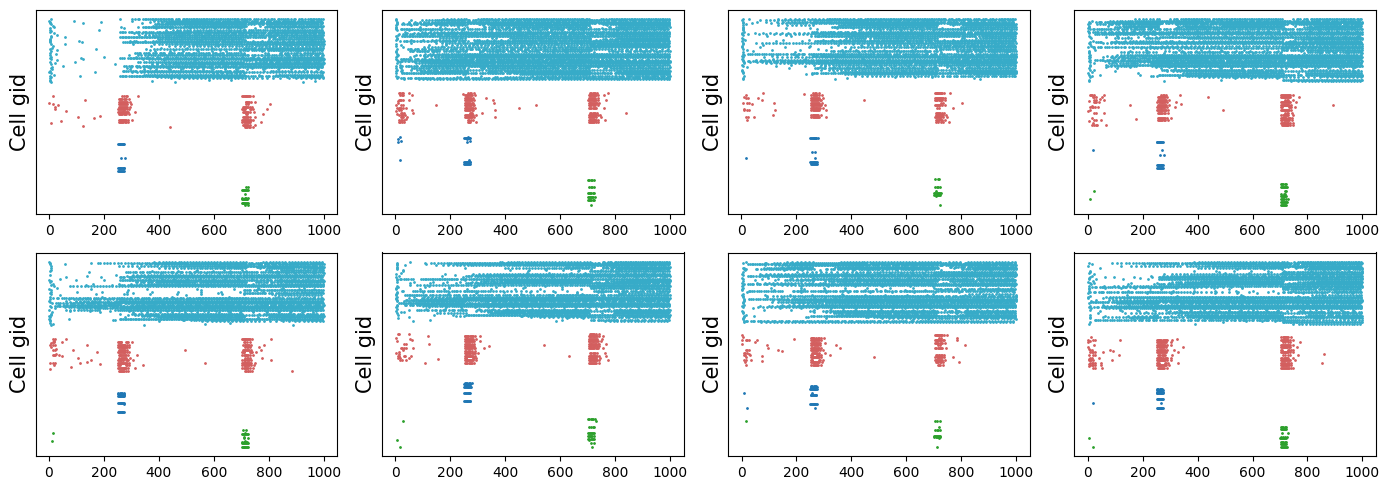

In [34]:
fontsize = 15
ticksize = 10
labelsize=13
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}
plt.figure(figsize=(14,5))
for plot_idx, sim_idx in enumerate(range(num_cond)):
    # sim_idx *= num_cond
    # sim_idx += 10
    
    plt.subplot(2,4, plot_idx+1)
    s = output_array[sim_idx, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=1, color=spike_color_dict[name])
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.yticks([])
    # plt.xlim(0, time_vec[-1])
    # plt.axvline(500 * dt, color='k', linestyle='--')
    # plt.title(input_names[plot_idx], fontsize=labelsize)
    plt.tight_layout()
    # plt.xlim(650, 700)

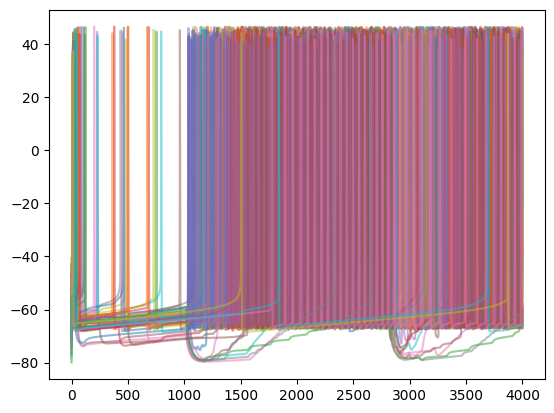

In [35]:
plt.plot(output_array[0, list(gid_ranges['E'])[:],:].T, alpha=0.5)
# plt.xlim(3000, 3100)

In [36]:
key_order, conn_names, biophysics_names = get_parameter_names()

# params is a list of single element dicitonaries, this is to just find the index
key_mapping = {list(param_dict.keys())[0]: idx for idx, param_dict in enumerate(params)}
theta_dict = {param_name: prior_dict[param_name]['rescale_function'](
    theta[theta_idx,param_idx], prior_dict[param_name]['bounds']) for 
    param_idx, param_name in enumerate(key_order)}
    
print(theta_dict)

{'cue_Esoma_ampa_gS': np.float64(1e-20), 'context_Esoma_ampa_gS': np.float64(1e-20), 'cue_Edend_ampa_gS': np.float64(0.09695801366459729), 'context_Edend_ampa_gS': np.float64(0.17061755573719808), 'cue_I_ampa_gS': np.float64(0.001), 'context_I_ampa_gS': np.float64(0.001), 'IE_gaba_gS': np.float64(0.01782691613802012), 'II_gaba_gS': np.float64(6.5277934925878655e-06), 'EI_ampa_gS': np.float64(1.1027271591663535e-07), 'EE_ampa_gS': np.float64(0.000575765082235168), 'IE_dend_gaba_gS': np.float64(0.11487215220082181), 'EE_dend_ampa_gS': np.float64(0.0012604548292241018), 'cue_Esoma_ampa_pconn': np.float64(0.0), 'context_Esoma_ampa_pconn': np.float64(0.0), 'cue_Edend_ampa_pconn': np.float64(0.4541779160499573), 'context_Edend_ampa_pconn': np.float64(0.4484331011772156), 'cue_I_ampa_pconn': np.float64(1.0), 'context_I_ampa_pconn': np.float64(1.0), 'IE_gaba_pconn': np.float64(0.08666970580816269), 'II_gaba_pconn': np.float64(0.11073693633079529), 'EI_ampa_pconn': np.float64(0.1633184999227523

In [7]:
explained_var_dict = dict()
for name in tqdm(random_init_dict.keys()):
    output_array = random_init_dict[name]['output_array']
    x_train = list()
    for sim_idx in range(0, output_array.shape[0], num_cond):
        temp_list = list()
        for cond_idx in range(num_cond):
            temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
        x_train.append(np.concatenate(temp_list, axis=1).T)

    pca = PCA()
    pca.fit(np.concatenate(x_train))
    explained_var_dict[name] = pca.explained_variance_ratio_

  0%|          | 0/7 [00:00<?, ?it/s]


TypeError: string indices must be integers, not 'str'

In [52]:
cond_names = {'cuedend_contextdend': 'Dend|Dend',
              'cuedend_contextsoma': 'Dend|Soma',
              'cuesoma_contextdend': 'Soma|Dend',
              'cuesoma_contextsoma': 'Soma|Soma'}

max_dim = 20
ticksize = 13
labelsize = 14
color_offset = 0
plt.figure()

for line_idx, (name, cond_label) in enumerate(cond_names.items()):
    exp_var = explained_var_dict[name]
    plt.plot(range(1, max_dim + 1), np.cumsum(exp_var[:max_dim]),
             label=cond_label, marker='.', markersize=10, color=f'C{line_idx}')
plt.legend(fontsize=labelsize)
plt.axhline(0.8, color='k', linestyle='--', linewidth=2, alpha=0.5, zorder=-10)
_ = plt.xticks(range(1, max_dim+1,2), labels=range(1, max_dim+1,2), fontsize=ticksize)
plt.yticks(fontsize=12)
plt.xlabel('Dimension', fontsize=labelsize)
plt.ylabel('Total Explained Variance (%)', fontsize=labelsize)

KeyError: 'cuedend_contextdend'

<Figure size 640x480 with 0 Axes>

Text(0, 0.5, 'Total Explained Variance (%)')

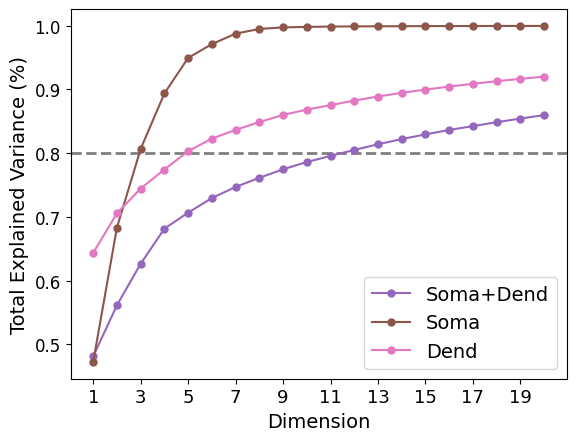

In [31]:
cond_names= {'cuesoma_contextsoma': 'Soma+Dend',
             'cuesoma_contextsoma_cellsoma': 'Soma',
             'cuesoma_contextsoma_celldend': 'Dend'}

color_offset = 4
plt.figure()

for line_idx, (name, cond_label) in enumerate(cond_names.items()):
    exp_var = explained_var_dict[name]
    plt.plot(range(1, max_dim + 1), np.cumsum(exp_var[:max_dim]),
             label=cond_label, marker='.', markersize=10, color=f'C{line_idx+color_offset}')
plt.legend(fontsize=labelsize)
plt.axhline(0.8, color='k', linestyle='--', linewidth=2, alpha=0.5, zorder=-10)
_ = plt.xticks(range(1, max_dim+1,2), labels=range(1, max_dim+1,2), fontsize=ticksize)
plt.yticks(fontsize=12)
plt.xlabel('Dimension', fontsize=labelsize)
plt.ylabel('Total Explained Variance (%)', fontsize=labelsize)


In [4]:
[1,2,3,4,5,6,7][::2]

[1, 3, 5, 7]